# 05 - Modelling 
This section is under active development.
## Objectives
The objective of this notebook is to predict the next-hour French day-ahead electricity price using market fundamentals and renewable generation features.

Because electricity prices exhibit strong temporal dependence, seasonality, and extreme scarcity events, the modelling approach emphasizes:

- Time-aware validation
- Leakage prevention
- Robust handling of non-linear relationships
- Separate evaluation of tail-price behavior 

## This notebook:

- Establishes benchmark models
- Engineers predictive features
- Trains a LightGBM model
- Evaluates forecasting performance
- Investigates model weakness

## Data
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno
import pyarrow

sys.path.append("../src")
import style 
style.apply_style()

import features
import data_split
import train
import evaluate
import plots

pd.set_option("display.max_columns", 50)

df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")

## Baseline models

In [2]:
df_baseline = df_alls.copy()

df_baseline["price_lag_23"] = df_baseline["Day-ahead Price (EUR/MWh)"].shift(23)

df_baseline = df_baseline.dropna(subset= ["price_lag_23"])

### Persistence model
The model assumes the next price will be equal to the current price.

In [3]:
df_baseline_train = df_baseline[(df_baseline.index.year >= 2016) & (df_baseline.index.year <= 2020)].copy()
df_baseline_val = df_baseline[df_baseline.index.year == 2021].copy()
df_baseline_test = df_baseline[df_baseline.index.year == 2022].copy()
df_baseline_recovery = df_baseline[(df_baseline.index.year >= 2023) & (df_baseline.index.year <= 2024)].copy()

In [4]:
pred_naive = df_baseline_val["Day-ahead Price (EUR/MWh)"]

### Previous day same hour
The model assumes that the price now equals to the price 24 hours ago because 
- demand cycles daily
- solar cycles daily
- human activities repeat daily

In [5]:
pred_23h = df_baseline_val["price_lag_23"]

In [6]:
print(df_baseline_val.index.equals(pred_23h.index))

True


## Feature engineering ML forecasting
### Target

In [7]:
col_modelling = [
    "Day-ahead Price (EUR/MWh)",
    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",
    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar"
]

df = df_alls[col_modelling].copy()
df["Actual Total Load (MW)_load"] = df["Actual Total Load (MW)_load"].interpolate()
df["target_price"] = df["Day-ahead Price (EUR/MWh)"].shift(-1)

### Calendar features

In [8]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

In [9]:
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

### Lag features & Rolling statistics (using "src/features.py")

In [10]:
df = features.add_price_features(df, lags = [1, 23, 24, 168], rolling_windows = [24, 72])

In [11]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78743 entries, 2016-01-08 00:00:00+01:00 to 2024-12-31 22:00:00+01:00
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Day-ahead Price (EUR/MWh)                78743 non-null  float64
 1   Actual Total Load (MW)_load              78743 non-null  float64
 2   Day-ahead Total Load Forecast (MW)_load  78743 non-null  float64
 3   Day-ahead (MW)_wind_onshore              78743 non-null  float64
 4   Day-ahead (MW)_solar                     78743 non-null  float64
 5   target_price                             78743 non-null  float64
 6   hour                                     78743 non-null  int32  
 7   dayofweek                                78743 non-null  int32  
 8   month                                    78743 non-null  int32  
 9   is_weekend                               78743 non-null  int64  
 10 

### Renewable features

In [12]:
df["renewable_ratio"] = (
    df["Day-ahead (MW)_solar"] +  
    df["Day-ahead (MW)_wind_onshore"] 
)/df["Day-ahead Total Load Forecast (MW)_load"]

### Scarcity / stress indicators

In [13]:
df["residual_load"] = (df["Day-ahead Total Load Forecast (MW)_load"] - (
    df["Day-ahead (MW)_solar"] 
    + df["Day-ahead (MW)_wind_onshore"]
    ))

df["high_residual_load"] = (
    df["residual_load"] > df["residual_load"].quantile(0.95)
).astype(int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78743 entries, 2016-01-08 00:00:00+01:00 to 2024-12-31 22:00:00+01:00
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Day-ahead Price (EUR/MWh)                78743 non-null  float64
 1   Actual Total Load (MW)_load              78743 non-null  float64
 2   Day-ahead Total Load Forecast (MW)_load  78743 non-null  float64
 3   Day-ahead (MW)_wind_onshore              78743 non-null  float64
 4   Day-ahead (MW)_solar                     78743 non-null  float64
 5   target_price                             78743 non-null  float64
 6   hour                                     78743 non-null  int32  
 7   dayofweek                                78743 non-null  int32  
 8   month                                    78743 non-null  int32  
 9   is_weekend                               78743 non-null  int64  
 10 

In [15]:
features_col = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dayofweek",
    "is_weekend",

    "Day-ahead Price (EUR/MWh)",
    "price_lag_1",
    "price_lag_23",
    "price_lag_24",
    "price_lag_168",
    "price_roll_mean_24",
    "price_roll_std_24",
    "price_roll_max_24",
    "price_roll_min_24",
    "price_roll_mean_72",
    "price_roll_std_72",
    "price_roll_max_72",
    "price_roll_min_72",

    "Actual Total Load (MW)_load",
    "Day-ahead Total Load Forecast (MW)_load",

    "Day-ahead (MW)_wind_onshore",
    "Day-ahead (MW)_solar",

    "renewable_ratio",
    "residual_load",
    "high_residual_load"
]

## Train test split
Since 2022 introduced an unprecedented market volatility due to the energy crisis in Europe, we will split the dataset accordingly to ensure model robustness under regime shifts. 

The training set will be 2016-2020, validation set will be 2021. 2022 will be used for stress test. 2023-2024 will be used for recovery and generalization test.

In [16]:
(X_train,
y_train,
X_val,
y_val,
X_test,
y_test,
X_recovery,
y_recovery
) = data_split.split_data(df, features_col)

## Gradient boosting modelling

In [17]:
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error 


In [18]:
model = LGBMRegressor(
    n_estimators = 300, 
    learning_rate = 0.05,
    max_depth = 6,
    num_leaves = 31,
    random_state = 42
)

In [19]:
train.train_regression(model, X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [20]:
y_val_pred = model.predict(X_val)

### Evaluation (using "src/evaluate.py")

In [21]:
evaluate.evaluate_regression(y_val, y_val_pred)

{'mae': 21.677769527900804, 'rmse': 50.79776702695631}

In [22]:
evaluation_results = []

evaluation_results.append({
    "model": "Lag-1 Persistence",
    **evaluate.evaluate_regression(y_val, pred_naive)
})

evaluation_results.append({
    "model": "Lag-23 Daily Baseline",
    **evaluate.evaluate_regression(y_val, pred_23h)
})

evaluation_results.append({
    "model": "LightGBM",
    **evaluate.evaluate_regression(y_val, y_val_pred)
})

eval_results_df = pd.DataFrame(evaluation_results)
eval_results_df

,model,mae,rmse
0,Lag-1 Persistence,9.049985,14.248442
1,Lag-23 Daily Baseline,19.739014,31.944053
2,LightGBM,21.677770,50.797767


## Baseline comparison and unexpected results

The lag-1 persistence benchmark substantially outperformed the current LightGBM implementation.

This indicates:
- either strong short-term autocorrelation dominates the signal,
- or there maybe feature/target alignment issues in the current pipeline.

Further investigation is required before finalizing the forecasting framework.

**Check the alignment manually:** (looks fine to me)

In [23]:
df[[
    "Day-ahead Price (EUR/MWh)",
    "target_price",
    "price_lag_1",
    "price_lag_23",
    "price_lag_24"
]].head(30)

,Day-ahead Price (EUR/MWh),target_price,price_lag_1,price_lag_23,price_lag_24
timestamp,,,,,
2016-01-08 00:00:00+01:00,24.36,19.33,28.76,26.05,26.41
2016-01-08 01:00:00+01:00,19.33,16.10,24.36,24.93,26.05
2016-01-08 02:00:00+01:00,16.10,15.00,19.33,22.39,24.93
2016-01-08 03:00:00+01:00,15.00,15.00,16.10,22.32,22.39
2016-01-08 04:00:00+01:00,15.00,18.14,15.00,24.20,22.32
2016-01-08 05:00:00+01:00,18.14,25.21,15.00,31.00,24.20
2016-01-08 06:00:00+01:00,25.21,36.46,18.14,42.47,31.00
2016-01-08 07:00:00+01:00,36.46,39.53,25.21,42.97,42.47
2016-01-08 08:00:00+01:00,39.53,37.69,36.46,41.93,42.97


**Checking the X/y split consistency:** (valided as the index equal is true)

In [24]:
X_train.index.equals(y_train.index)

True

### more investigations needed to improve the LGBM model

### Plots (using "src/plots.py")

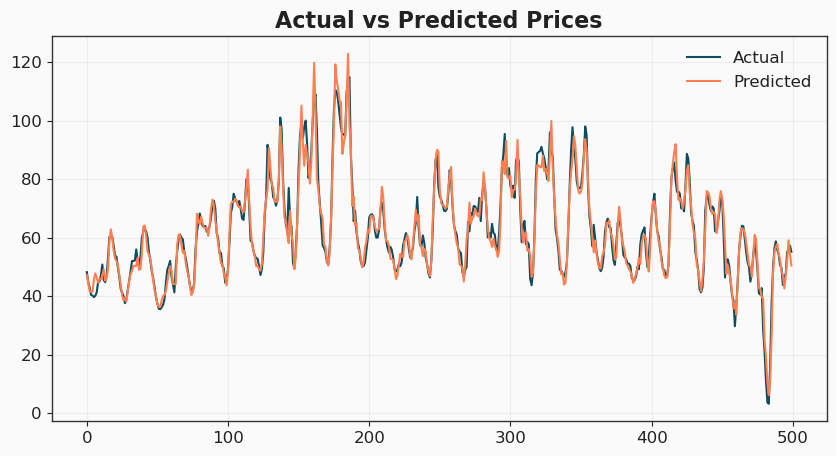

In [25]:
plots.plot_actual_pred_diff(y_val, y_val_pred)

The model has nicely captured the cyclic features of the actual price, as well as the overall trend. The extreme spikes are less accurately predicted. 

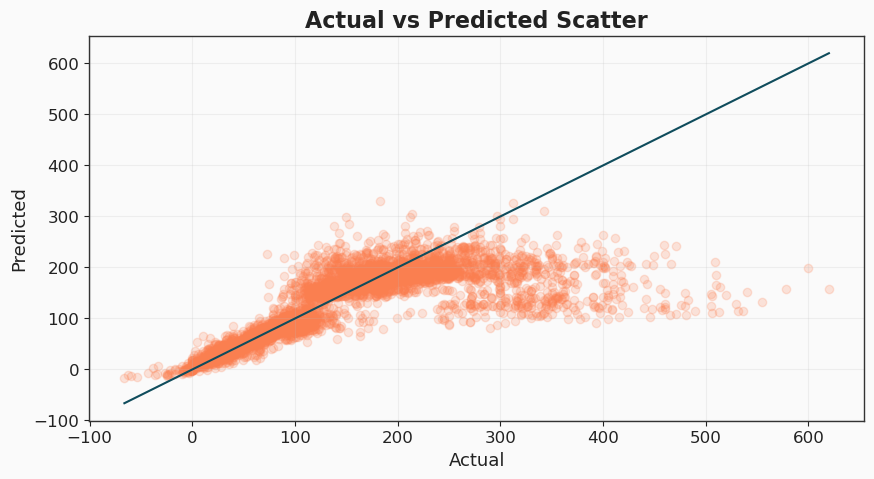

In [26]:
plots.plot_actual_pred_scatter(y_val, y_val_pred)

The scatter plot reveals that the model can handle low range price prediction very well, but lose focus when the actual price reaches 100 EUR/MWh.

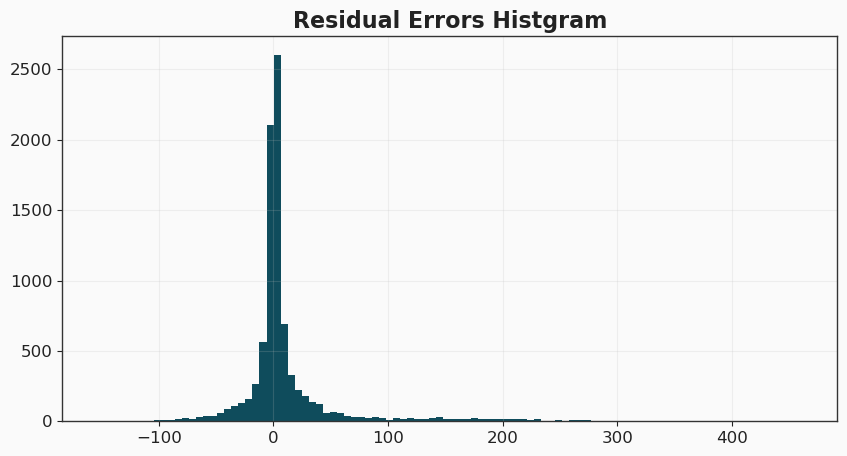

In [27]:
plots.plot_residual(y_val, y_val_pred)

The long positive tail in the histgram of residual errors for the validation set reveals that the model underpredicts extreme incidents. Based on these feedbacks, we will continue to improve the model by introducing tail-performance analysis.
### Tail-performance analysis

In [28]:
tail_threshold = y_val.quantile(0.95)
tail_mask = y_val >= tail_threshold

In [29]:
mae_tail_val = mean_absolute_error(
    y_val[tail_mask],
    y_val_pred[tail_mask]
)

mae_norm_val = mean_absolute_error(
    y_val[~tail_mask],
    y_val_pred[~tail_mask]
)

print("Validation Set MAE Tail", mae_tail_val, "\n", "Validation Set MAE Norm", mae_norm_val)

Validation Set MAE Tail 183.31016857980836 
 Validation Set MAE Norm 13.170801156747775


The model performs well for 95% of the time, while the 5% extreme cases the model fails to perform.

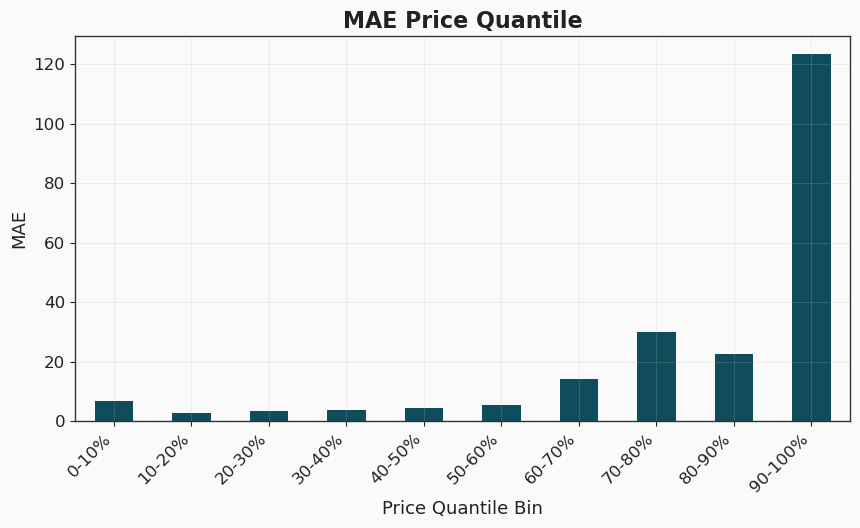

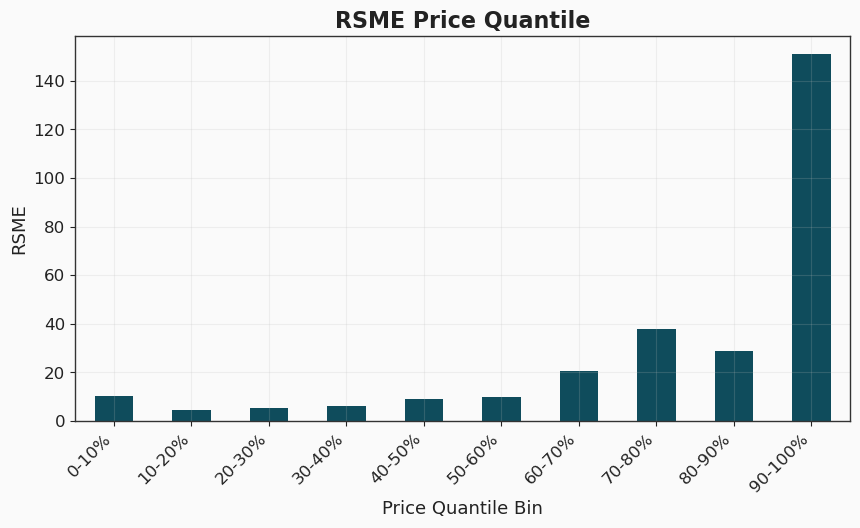

In [30]:
plots.plot_error_by_price_quantile(y_val, y_val_pred)

Model prediction errors increase sharply in the upper price quantiles, indicating that scarcity-driven price regimes remain difficult to model. This behavior is consistent with the steep upper-tail structure observed in the residual load duration curve in notebook 03.

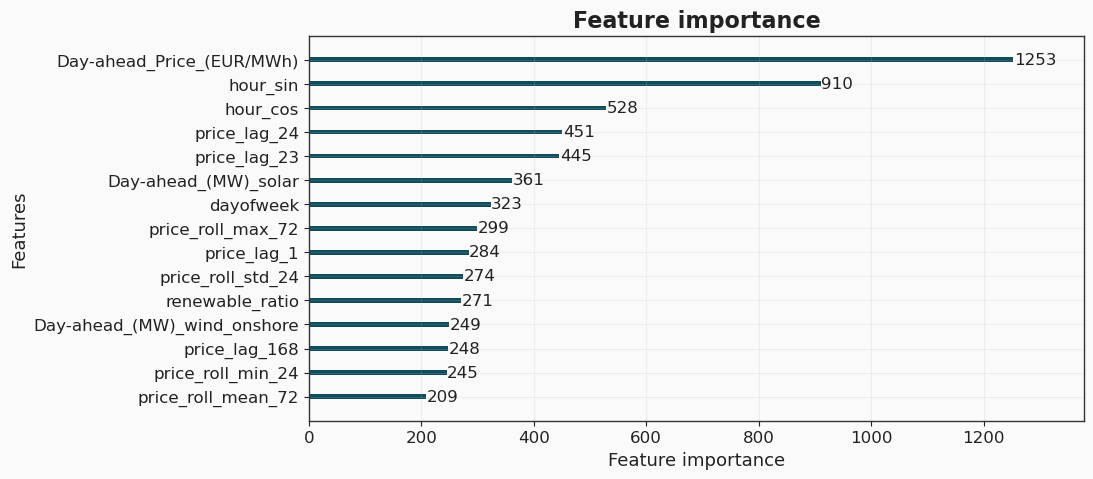

In [31]:
plots.plot_feature_importance(model)

Lightgbm feature importance indicates day-ahead price is the most influencial, followed by hour, rolling volatility and price lag are the top features. However, it is important to keep in mind that many other features overlaps with these top features, such as solar generations.

## Discussion

The current LightGBM model does not outperform the simple persistence baseline.

This result is not uncommon in electricity price forecasting, where strong autocorrelation allows naive models to perform surprisingly well.

Several factors may explain the performance gap:

- The feature set may not fully capture scarcity events.
- Price spikes represent a small fraction of observations but contribute heavily to prediction error.
- The current LightGBM model uses default hyperparameters.
- Additional lag features and market indicators may be required.

Future work will focus on time-series cross-validation, hyperparameter optimization, and improved treatment of extreme price events.


# Conclusions

The objective of this notebook was to predict the next-hour French day-ahead electricity price using historical market data.

Key findings:

- Lag-based persistence models provide a surprisingly strong benchmark.
- The current LightGBM model underperforms the naive baseline.
- Model errors are concentrated in extreme price regimes.
- Scarcity events remain the main challenge for accurate forecasting.

Future improvements include:

- Time-series cross-validation
- Hyperparameter optimization
- Additional lag and rolling features
- Explicit modelling of extreme price events
- Comparison with XGBoost and CatBoost